In [77]:
from __future__ import annotations

import re
from pathlib import Path

import math
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_dataset
from IPython.display import display

def estimate_pass_at_k(num_samples: int, num_correct: int, k: int) -> float:
    """Estimate pass@k for one prompt."""
    if num_samples < 1:
        raise ValueError(f"num_samples must be >= 1, got {num_samples}.")
    if not (0 <= num_correct <= num_samples):
        raise ValueError(
            f"num_correct must satisfy 0 <= num_correct <= num_samples, got {num_correct} with {num_samples}."
        )
    if not (1 <= k <= num_samples):
        raise ValueError(f"k must satisfy 1 <= k <= num_samples, got {k} with {num_samples}.")
    if num_samples - num_correct < k:
        return 1.0
    return 1.0 - (math.comb(num_samples - num_correct, k) / math.comb(num_samples, k))

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

DATASET_REPO = "mnoukhov/aime2024-25-rlvr-olmo3-7b-base-pass64-quartiles"
DATASET_SPLIT = "test"
EVAL_CSV_PATH = Path("../notebooks/wandb_export.csv")
REPO_OR_NOTEBOOK_DIR = Path.cwd()
OUTPUT_DIR = (REPO_OR_NOTEBOOK_DIR if REPO_OR_NOTEBOOK_DIR.name == "notebooks" else REPO_OR_NOTEBOOK_DIR / "notebooks") / "figures"

In [78]:
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [re.sub(r"[^0-9a-zA-Z]+", "_", col.strip().lower()).strip("_") for col in df.columns]
    return df


def parse_step_from_name(name: str) -> int:
    match = re.search(r"step_(\d+)", str(name))
    if match is None:
        raise ValueError(f"Could not parse a step from {name!r}")
    return int(match.group(1))


def load_baseline(dataset_repo: str, split: str) -> pd.DataFrame:
    ds = load_dataset(dataset_repo, split=split)
    df = normalize_columns(ds.to_pandas())

    if "dataset_index" not in df.columns:
        if "index" in df.columns:
            df = df.rename(columns={"index": "dataset_index"})
        else:
            df["dataset_index"] = np.arange(len(df), dtype=int)

    if "pass_count" not in df.columns:
        if "pass_rate" not in df.columns:
            raise ValueError("The baseline dataset needs pass_count or pass_rate.")
        df["pass_count"] = df["pass_rate"].map(lambda value: int(str(value).split("/", 1)[0]))

    required_columns = {"dataset_index", "dataset", "num_samples", "pass_count"}
    missing = required_columns - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    df["dataset_index"] = pd.to_numeric(df["dataset_index"], errors="raise").astype(int)
    df["num_samples"] = pd.to_numeric(df["num_samples"], errors="raise").astype(int)
    df["pass_count"] = pd.to_numeric(df["pass_count"], errors="raise").astype(int)
    df["initial_pass_at_1"] = [
        estimate_pass_at_k(num_samples=int(num_samples), num_correct=int(pass_count), k=1)
        for pass_count, num_samples in zip(df["pass_count"], df["num_samples"])
    ]
    df["quartile"] = df["dataset"].astype(str).str.extract(r"quartile(\d+)").astype("Int64")

    return df[["dataset_index", "dataset", "quartile", "pass_count", "num_samples", "initial_pass_at_1"]]


def load_eval_csv(path: Path) -> pd.DataFrame:
    df = normalize_columns(pd.read_csv(path))

    if "dataset_index" not in df.columns:
        if "index" in df.columns:
            df = df.rename(columns={"index": "dataset_index"})
        else:
            raise ValueError("The eval CSV needs a dataset_index column.")

    if "solve_rate" not in df.columns:
        if "pass_rate" in df.columns:
            df = df.rename(columns={"pass_rate": "solve_rate"})
        else:
            raise ValueError("The eval CSV needs a solve_rate column.")

    if "step" not in df.columns:
        if "name" not in df.columns:
            raise ValueError("The eval CSV needs either a step column or a name column containing step_XXXX.")
        df["step"] = df["name"].map(parse_step_from_name)

    df["dataset_index"] = pd.to_numeric(df["dataset_index"], errors="raise").astype(int)
    df["solve_rate"] = pd.to_numeric(df["solve_rate"], errors="raise")
    df["step"] = pd.to_numeric(df["step"], errors="raise").astype(int)

    return df


In [79]:
baseline = load_baseline(DATASET_REPO, DATASET_SPLIT)
eval_df = load_eval_csv(EVAL_CSV_PATH)

merged = eval_df.merge(
    baseline,
    on="dataset_index",
    how="left",
    validate="many_to_one",
)
merged["delta_vs_initial_pass_at_1"] = merged["solve_rate"] - merged["initial_pass_at_1"]
merged = merged.sort_values(["quartile", "dataset_index", "step"]).reset_index(drop=True)

display(merged.head())
display(merged[["step", "delta_vs_initial_pass_at_1"]].groupby("step", as_index=False).mean())


,dataset_index,id,name,solve_rate,step,dataset,quartile,pass_count,num_samples,initial_pass_at_1,delta_vs_initial_pass_at_1
0,0,6n2jlr5r,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,0.781250,200,math_aime_quartile0,0,22,64,0.34375,0.437500
1,0,eh5wi7gu,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,0.859375,400,math_aime_quartile0,0,22,64,0.34375,0.515625
2,0,yoqi90ri,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,0.906250,600,math_aime_quartile0,0,22,64,0.34375,0.562500
3,0,p9bx5c8r,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,0.953125,800,math_aime_quartile0,0,22,64,0.34375,0.609375
4,0,j29e73ju,olmo31_7b_rlzero_math_eval_all_checkpoints_ste...,0.906250,1000,math_aime_quartile0,0,22,64,0.34375,0.562500


,step,delta_vs_initial_pass_at_1
0,200,0.125000
1,400,0.137760
2,600,0.159896
3,800,0.166406
4,1000,0.185677
5,1200,0.191667
6,1400,0.189844
7,1600,0.199740
8,1800,0.210677
9,2000,0.209896


In [80]:
final_step = int(merged["step"].max())
final_df = merged[merged["step"] == final_step]

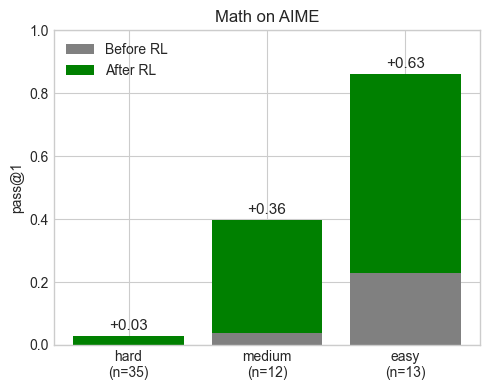

In [81]:
final_with_pc = final_df[["dataset_index", "pass_count", "initial_pass_at_1", "solve_rate"]].copy()

hard_mask = final_with_pc["pass_count"] == 0
hard = final_with_pc[hard_mask]
remainder = final_with_pc[~hard_mask].sort_values("initial_pass_at_1", ascending=True).reset_index(drop=True)

split_point = len(remainder) // 2
medium = remainder.iloc[:split_point]
easy = remainder.iloc[split_point:]

math_groups = {"hard": hard, "medium": medium, "easy": easy}
math_labels = list(math_groups.keys())
math_initial = np.array([g["initial_pass_at_1"].mean() if len(g) else 0.0 for g in math_groups.values()])
math_final = np.array([g["solve_rate"].mean() if len(g) else 0.0 for g in math_groups.values()])
math_delta = np.clip(math_final - math_initial, a_min=0, a_max=None)
math_counts = [len(g) for g in math_groups.values()]
math_xticklabels = [f"{label}\n(n={n})" for label, n in zip(math_labels, math_counts)]

fig, ax = plt.subplots(figsize=(5, 4))
x = np.arange(len(math_labels))
ax.bar(x, math_initial, color="grey", label="Before RL")
ax.bar(x, math_delta, bottom=math_initial, color="green", label="After RL")

for xi, init_val, delta_val in zip(x, math_initial, math_delta):
    ax.text(xi, init_val + delta_val + 0.01, f"+{delta_val:.2f}", ha="center", va="bottom", fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(math_xticklabels)
ax.set_ylabel("pass@1")
ax.set_title("Math on AIME")
ax.set_ylim(0, min(1.0, float((math_initial + math_delta).max()) + 0.15))
ax.legend()
plt.tight_layout()
plt.show()

In [82]:
extracted_buckets = [
    {"bucket": "0/8", "group": "extra hard", "n": 99,  "base": 0,   "after_rl": 5,  "delta": 5},
    {"bucket": "1/8", "group": "hard",       "n": 9,   "base": 12,  "after_rl": 18, "delta": 6},
    {"bucket": "2/8", "group": "hard",       "n": 8,   "base": 25,  "after_rl": 48, "delta": 23},
    {"bucket": "3/8", "group": "hard",       "n": 6,   "base": 38,  "after_rl": 44, "delta": 6},
    {"bucket": "4/8", "group": "medium",     "n": 8,   "base": 50,  "after_rl": 67, "delta": 17},
    {"bucket": "5/8", "group": "medium",     "n": 10,  "base": 62,  "after_rl": 89, "delta": 26},
    {"bucket": "6/8", "group": "medium",     "n": 23,  "base": 75,  "after_rl": 92, "delta": 17},
    {"bucket": "7/8", "group": "easy",       "n": 15,  "base": 88,  "after_rl": 92, "delta": 4},
    {"bucket": "8/8", "group": "easy",       "n": 101, "base": 100, "after_rl": 98, "delta": -2},
]

initial_pass_rate_to_increase_after_rl = {
    0: 5,
    12: 6,
    25: 23,
    38: 6,
    50: 17,
    62: 26,
    75: 17,
    88: 4,
    100: -2,
}

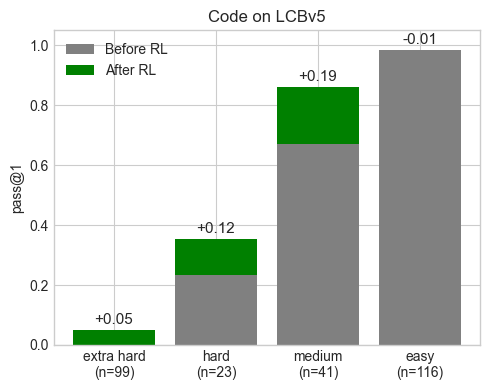

In [83]:
CODE_GROUPS = {
    "easy": {"7/8", "8/8"},
    "medium": {"4/8", "5/8", "6/8"},
    "hard": {"1/8", "2/8", "3/8"},
    "extra hard": {"0/8"},
}

buckets_df = pd.DataFrame(extracted_buckets)

code_labels = ["extra hard", "hard", "medium", "easy"]
code_initial_list = []
code_delta_list = []
code_counts = []
for label in code_labels:
    sub = buckets_df[buckets_df["bucket"].isin(CODE_GROUPS[label])]
    n = int(sub["n"].sum())
    code_counts.append(n)
    if n > 0:
        code_initial_list.append((sub["base"] * sub["n"]).sum() / n / 100.0)
        code_delta_list.append((sub["delta"] * sub["n"]).sum() / n / 100.0)
    else:
        code_initial_list.append(0.0)
        code_delta_list.append(0.0)

code_initial = np.array(code_initial_list)
code_delta_signed = np.array(code_delta_list)
code_delta = np.clip(code_delta_signed, a_min=0, a_max=None)
code_xticklabels = [f"{label}\n(n={n})" for label, n in zip(code_labels, code_counts)]

fig, ax = plt.subplots(figsize=(5, 4))
x = np.arange(len(code_labels))
ax.bar(x, code_initial, color="grey", label="Before RL")
ax.bar(x, code_delta, bottom=code_initial, color="green", label="After RL")

for xi, init_val, delta_val in zip(x, code_initial, code_delta_signed):
    top = init_val + max(delta_val, 0)
    sign = "+" if delta_val >= 0 else ""
    ax.text(xi, top + 0.01, f"{sign}{delta_val:.2f}", ha="center", va="bottom", fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(code_xticklabels)
ax.set_ylabel("pass@1")
ax.set_title("Code on LCBv5")
ax.set_ylim(0, min(1.05, float((code_initial + code_delta).max()) + 0.15))
ax.legend()
plt.tight_layout()
plt.show()

In [84]:
extracted_difficulty_buckets = [
    {"difficulty": "<15 min fix",      "n": 194, "qwen3": 33.1, "deepswe": 51.5, "delta": 18.4},
    {"difficulty": "15 min - 1 hour", "n": 261, "qwen3": 14.7, "deepswe": 27.0, "delta": 12.3},
    {"difficulty": "1-4 hours",       "n": 42,  "qwen3": 2.9,  "deepswe": 8.6,  "delta": 5.7},
    {"difficulty": ">4 hours",        "n": 3,   "qwen3": 0.0,  "deepswe": 0.0,  "delta": 0.0},
]

initial_pass_rate_to_increase = {
    33.1: 18.4,
    14.7: 12.3,
    2.9: 5.7,
    0.0: 0.0,
}

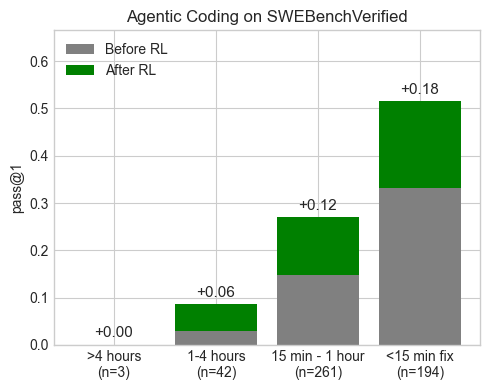

In [85]:
agentic_df = pd.DataFrame(extracted_difficulty_buckets)

agentic_labels = [">4 hours", "1-4 hours", "15 min - 1 hour", "<15 min fix"]
agentic_df = agentic_df.set_index("difficulty").loc[agentic_labels].reset_index()

agentic_initial = agentic_df["qwen3"].to_numpy() / 100.0
agentic_delta_signed = agentic_df["delta"].to_numpy() / 100.0
agentic_delta = np.clip(agentic_delta_signed, a_min=0, a_max=None)
agentic_counts = agentic_df["n"].to_numpy()
agentic_xticklabels = [f"{label}\n(n={n})" for label, n in zip(agentic_labels, agentic_counts)]

fig, ax = plt.subplots(figsize=(5, 4))
x = np.arange(len(agentic_labels))
ax.bar(x, agentic_initial, color="grey", label="Before RL")
ax.bar(x, agentic_delta, bottom=agentic_initial, color="green", label="After RL")

for xi, init_val, delta_val in zip(x, agentic_initial, agentic_delta_signed):
    top = init_val + max(delta_val, 0)
    sign = "+" if delta_val >= 0 else ""
    ax.text(xi, top + 0.01, f"{sign}{delta_val:.2f}", ha="center", va="bottom", fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(agentic_xticklabels)
ax.set_ylabel("pass@1")
ax.set_title("Agentic Coding on SWEBenchVerified")
ax.set_ylim(0, min(1.05, float((agentic_initial + agentic_delta).max()) + 0.15))
ax.legend()
plt.tight_layout()
plt.show()

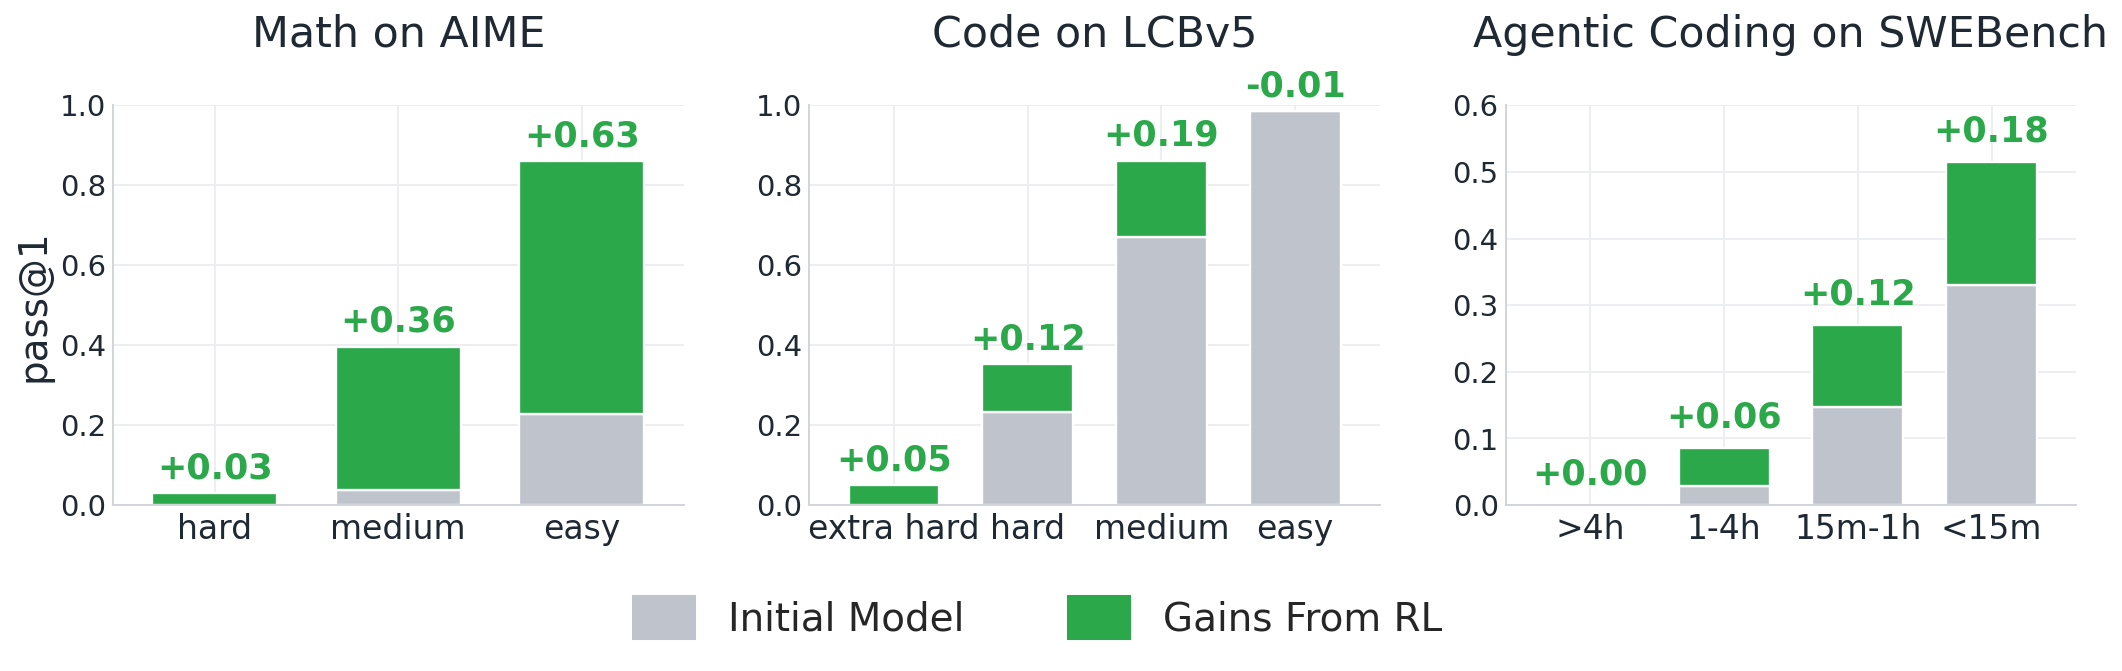

In [ ]:
INITIAL_COLOR = "#8C8C8C"
GAIN_COLOR = "#55A868"
TEXT_COLOR = "#1F2933"

panels = [
    {
        "title": "Math on AIME",
        "labels": math_labels,
        "initial": math_initial,
        "delta_signed": math_delta,
        "ymax": 1.0,
    },
    {
        "title": "Code on LCBv5",
        "labels": code_labels,
        "initial": code_initial,
        "delta_signed": code_delta_signed,
        "ymax": 1.0,
    },
    {
        "title": "Agentic Coding on SWEBench",
        "labels": [">4h", "1-4h", "15m-1h", "<15m"],
        "initial": agentic_initial,
        "delta_signed": agentic_delta_signed,
        "ymax": 0.6,
    },
]

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.labelcolor": TEXT_COLOR,
    "xtick.color": TEXT_COLOR,
    "ytick.color": TEXT_COLOR,
})

bar_width = 0.68

fig, axes = plt.subplots(1, 3, figsize=(15, 5.1), dpi=140)
fig.patch.set_facecolor("white")

before_handle = mpatches.Patch(facecolor=INITIAL_COLOR, edgecolor="white",
                               label="Initial Model")
after_handle = mpatches.Patch(facecolor=GAIN_COLOR, edgecolor="white",
                              label="Gains From RL")

for i, (ax, panel) in enumerate(zip(axes, panels)):
    x = np.arange(len(panel["labels"]))
    initial = np.asarray(panel["initial"], dtype=float)
    delta = np.asarray(panel["delta_signed"], dtype=float)
    pos_delta = np.clip(delta, 0, None)

    ax.bar(x, initial, width=bar_width, color=INITIAL_COLOR,
           edgecolor="white", linewidth=1.2, zorder=2)
    ax.bar(x, pos_delta, width=bar_width, bottom=initial, color=GAIN_COLOR,
           edgecolor="white", linewidth=1.2, zorder=2)

    for xi, init_val, delta_val in zip(x, initial, delta):
        top = init_val + max(delta_val, 0)
        sign = "+" if delta_val >= 0 else ""
        ax.text(xi, top + 0.02, f"{sign}{delta_val:.2f}",
                ha="center", va="bottom",
                fontsize=18, color=GAIN_COLOR, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(panel["labels"], fontsize=17)
    ax.tick_params(axis="x", length=0, pad=4)
    ax.tick_params(axis="y", labelsize=15, length=0)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, color="#ECEEF1", linewidth=1.0, zorder=0)
    ax.xaxis.grid(True, color="#ECEEF1", linewidth=1.0, zorder=0)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines["left"].set_color("#D1D5DB")
    ax.spines["bottom"].set_color("#D1D5DB")
    ax.set_title(panel["title"], fontsize=22, pad=30, color=TEXT_COLOR)
    ax.set_ylim(0, panel["ymax"])
    ax.margins(x=0.08)

    if i == 0:
        ax.set_ylabel("pass@1", fontsize=20, color=TEXT_COLOR)

fig.legend(
    handles=[before_handle, after_handle],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.04),
    ncol=2,
    frameon=False,
    fontsize=20,
    handlelength=1.7,
    handleheight=1.5,
    columnspacing=2.6,
)

fig.subplots_adjust(left=0.06, right=0.995, top=0.84, bottom=0.28, wspace=0.22)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTPUT_DIR / "matthew_main.pdf", bbox_inches="tight")
plt.show()

In [ ]:
percent_panels = []
for panel in panels:
    initial = np.asarray(panel["initial"], dtype=float)
    delta_signed = np.asarray(panel["delta_signed"], dtype=float)
    percent_improvement = np.full_like(delta_signed, np.nan, dtype=float)
    valid_initial = initial > 0
    percent_improvement[valid_initial] = 100 * delta_signed[valid_initial] / initial[valid_initial]

    percent_panels.append(
        {
            "title": panel["title"],
            "labels": panel["labels"],
            "percent_improvement": percent_improvement,
        }
    )

fig, axes = plt.subplots(1, 3, figsize=(15, 4.1), dpi=140)
fig.patch.set_facecolor("white")

for i, (ax, panel) in enumerate(zip(axes, percent_panels)):
    x = np.arange(len(panel["labels"]))
    values = panel["percent_improvement"]
    finite_values = values[np.isfinite(values)]
    ymax = max(10, float(finite_values.max()) * 1.2) if len(finite_values) else 10
    ymin = min(0, float(finite_values.min()) * 1.2) if len(finite_values) else 0

    colors = [rl_color if value >= 0 else "#B43B3B" for value in np.nan_to_num(values, nan=0.0)]
    ax.bar(x, np.nan_to_num(values, nan=0.0), width=bar_width, color=colors)
    ax.axhline(0, color="#555555", linewidth=1)

    for xi, value in zip(x, values):
        if np.isfinite(value):
            va = "bottom" if value >= 0 else "top"
            offset = ymax * 0.025 if value >= 0 else -ymax * 0.025
            ax.text(
                xi,
                value + offset,
                f"{value:+.0f}%",
                ha="center",
                va=va,
                fontsize=14,
                color="#333333",
            )
        else:
            ax.text(xi, ymax * 0.04, "n/a", ha="center", va="bottom", fontsize=13, color="#555555")

    ax.set_xticks(x)
    ax.set_xticklabels(panel["labels"], fontsize=16)
    ax.tick_params(axis="x", length=0, pad=4)
    ax.tick_params(axis="y", labelsize=12, length=0)
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="#D0D0D0", linewidth=0.8, alpha=0.65)
    ax.grid(axis="x", visible=False)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines["left"].set_color("#C7C7C7")
    ax.spines["bottom"].set_color("#C7C7C7")
    ax.set_title(panel["title"], fontsize=17, pad=8)
    ax.set_ylim(ymin, ymax)

    if i == 0:
        ax.set_ylabel("% improvement over initial", fontsize=16)

fig.subplots_adjust(left=0.075, right=0.995, top=0.86, bottom=0.16, wspace=0.24)
plt.show()